
Actual vs Predicted Education Level
   Experience_Years Actual Education_Level Predicted Education_Level
0                 0                 Master                  Bachelor
1                 2                 Master                    Master
2                 0               Bachelor                  Bachelor
3                 0                 Master                    Master
4                18                 Master                  Bachelor
5                19                 Master                    Master
6                17               Bachelor                  Bachelor
7                 2               Bachelor                  Bachelor
8                14               Bachelor                  Bachelor
9                 1               Bachelor                  Bachelor

Accuracy: 0.6433333333333333


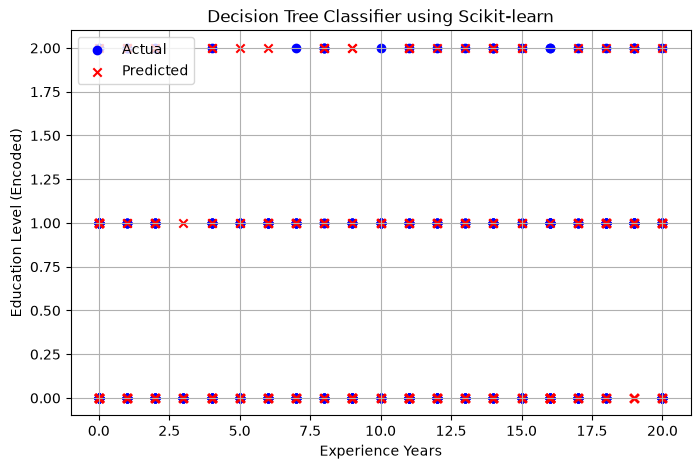

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

df = pd.read_csv('preprocessed_data.csv')
X = df[["Age",
        "Experience_Years",
        "Job_Level",
        "Performance_Score",
        "Weekly_Working_Hours",
        "Salary_LPA"]]
y = df["Education_Level"]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
result = pd.DataFrame({
    "Experience_Years": X_test["Experience_Years"].values,
    "Actual Education_Level": label_encoder.inverse_transform(y_test),
    "Predicted Education_Level": label_encoder.inverse_transform(y_pred)
})

print("\nActual vs Predicted Education Level")
print(result.head(10))
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
plt.figure(figsize=(8, 5))
plt.scatter(
    X_test["Experience_Years"],
    y_test,
    color="blue",
    label="Actual"
)

plt.scatter(
    X_test["Experience_Years"],
    y_pred,
    color="red",
    marker="x",
    label="Predicted"
)

plt.title("Decision Tree Classifier using Scikit-learn")
plt.xlabel("Experience Years")
plt.ylabel("Education Level (Encoded)")
plt.legend()
plt.grid(True)

plt.show()